# Cardiotocography (CTG) End-to-End Classification 


### 0. Install and import dependencies

Objective: make the notebook self-contained so it can run in a fresh environment. The next cell installs missing packages (if needed), imports all required libraries, sets plotting style, and sets a fixed random seed for reproducibility.

In [30]:
import importlib
import subprocess
import sys

# Install required packages only if they are missing.
required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "xlrd": "xlrd"
}

missing = []
for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

import warnings
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment setup complete.")

All required packages are already installed.
Environment setup complete.


## 1. load CTG dataset from local Excel file


In [31]:
# Use your local file path as default.
DATA_PATH = Path(r"E:/deletable/cardiotocography/CTG.xls")

# Optional fallback if notebook is moved but CTG.xls is in the same folder.
if not DATA_PATH.exists():
    DATA_PATH = Path("CTG.xls")

if not DATA_PATH.exists():
    raise FileNotFoundError("Could not find CTG.xls. Please check the file path.")

raw_data = pd.read_excel(DATA_PATH, sheet_name="Data", header=None)

# In this file, row index 1 stores column names.
# Feature columns are at positions 10 to 30, and target NSP is at position 45.
feature_names = raw_data.iloc[1, 10:31].tolist()

df = raw_data.iloc[2:2128, 10:31].copy()
df.columns = feature_names
df["NSP"] = raw_data.iloc[2:2128, 45].values

# Convert all values to numeric and keep valid target rows.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["NSP"]).reset_index(drop=True)
df["NSP"] = df["NSP"].astype(int)

print(f"Loaded dataset shape: {df.shape}")
print(f"Using file: {DATA_PATH}")

Loaded dataset shape: (2126, 22)
Using file: E:\deletable\cardiotocography\CTG.xls


## 2. Data loading 

The printed shape should be close to 2126 rows and 22 columns (21 features + 1 target). If shape is very different, check whether the wrong Excel sheet or rows were selected.

### 2.1 first data inspection

Objective: quickly check structure, datatypes, summary statistics, and missing values before any preprocessing.

In [32]:
display(df.head())



,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,NSP
0,120,0.000000,0.0,0.000000,0.000000,0.0,0.0,73,0.5,43,...,62,126,2,0,120,137,121,73,1,2
1,132,0.006380,0.0,0.006380,0.003190,0.0,0.0,17,2.1,0,...,68,198,6,1,141,136,140,12,0,1
2,133,0.003322,0.0,0.008306,0.003322,0.0,0.0,16,2.1,0,...,68,198,5,1,141,135,138,13,0,1
3,134,0.002561,0.0,0.007682,0.002561,0.0,0.0,16,2.4,0,...,53,170,11,0,137,134,137,13,1,1
4,132,0.006515,0.0,0.008143,0.000000,0.0,0.0,16,2.4,0,...,53,170,9,0,137,136,138,11,1,1


In [33]:
print("\nInfo:")
df.info()



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2126 non-null   int64  
 1   AC        2126 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2126 non-null   float64
 6   DP        2126 non-null   float64
 7   ASTV      2126 non-null   int64  
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   int64  
 10  MLTV      2126 non-null   float64
 11  Width     2126 non-null   int64  
 12  Min       2126 non-null   int64  
 13  Max       2126 non-null   int64  
 14  Nmax      2126 non-null   int64  
 15  Nzeros    2126 non-null   int64  
 16  Mode      2126 non-null   int64  
 17  Mean      2126 non-null   int64  
 18  Median    2126 non-null   int64  
 19  Variance  2126 non-null   int64  
 20  Tendency  2126 non-null   int64  


In [34]:
print("\nDescriptive statistics:")
display(df.describe().T)



Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
LB,2126.0,133.303857,9.840844,106.0,126.000000,133.000000,140.000000,160.000000
AC,2126.0,0.003170,0.003860,0.0,0.000000,0.001630,0.005631,0.019284
FM,2126.0,0.009474,0.046670,0.0,0.000000,0.000000,0.002512,0.480634
UC,2126.0,0.004357,0.002940,0.0,0.001876,0.004482,0.006525,0.014925
DL,2126.0,0.001885,0.002962,0.0,0.000000,0.000000,0.003264,0.015385
DS,2126.0,0.000004,0.000063,0.0,0.000000,0.000000,0.000000,0.001353
DP,2126.0,0.000157,0.000580,0.0,0.000000,0.000000,0.000000,0.005348
ASTV,2126.0,46.990122,17.192814,12.0,32.000000,49.000000,61.000000,87.000000
MSTV,2126.0,1.332785,0.883241,0.2,0.700000,1.200000,1.700000,7.000000
ALTV,2126.0,9.846660,18.396880,0.0,0.000000,0.000000,11.000000,91.000000


In [35]:
missing_counts = df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:")
display(missing_counts[missing_counts > 0])



Missing values per column:


Series([], dtype: int64)

In [36]:
if missing_counts.sum() == 0:
    print("No missing values found.")

No missing values found.



You now have a baseline understanding of the dataset. Keep an eye on unusual ranges, high variance, and missing-value patterns because they influence model choice and preprocessing.

### 3. Understand the target and class balance

Objective: inspect target classes (`NSP`), map them to human-readable names, and detect whether class imbalance is present.

In [37]:
target_map = {1: "Normal", 2: "Suspect", 3: "Pathologic"}

class_counts = df["NSP"].value_counts().sort_index()
class_percent = (class_counts / len(df) * 100).round(2)

class_summary = pd.DataFrame({
    "Class": [target_map.get(c, str(c)) for c in class_counts.index],
    "Count": class_counts.values,
    "Percentage": class_percent.values
}, index=class_counts.index)

display(class_summary)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print("Imbalance detected?", "Yes" if imbalance_ratio > 1.5 else "No")

,Class,Count,Percentage
NSP,,,
1,Normal,1655,77.85
2,Suspect,295,13.88
3,Pathologic,176,8.28


Imbalance ratio (max/min): 9.40
Imbalance detected? Yes


If imbalance is reported as `Yes`, we should use techniques like `SMOTE` or class weights during training so minority classes are not ignored by the model.

### 4. Exploratory data analysis (EDA)

Objective: visualize relationships and distributions using a correlation heatmap, feature distributions, boxplots for outliers, target distribution, and feature-vs-target behavior.

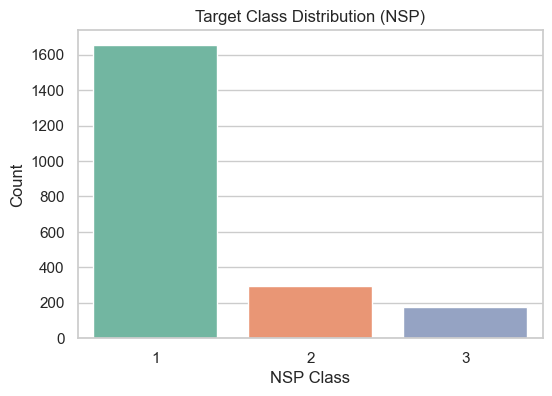

In [38]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="NSP", data=df, hue="NSP", palette="Set2", legend=False)
plt.title("Target Class Distribution (NSP)")
plt.xlabel("NSP Class")
plt.ylabel("Count")
plt.show()

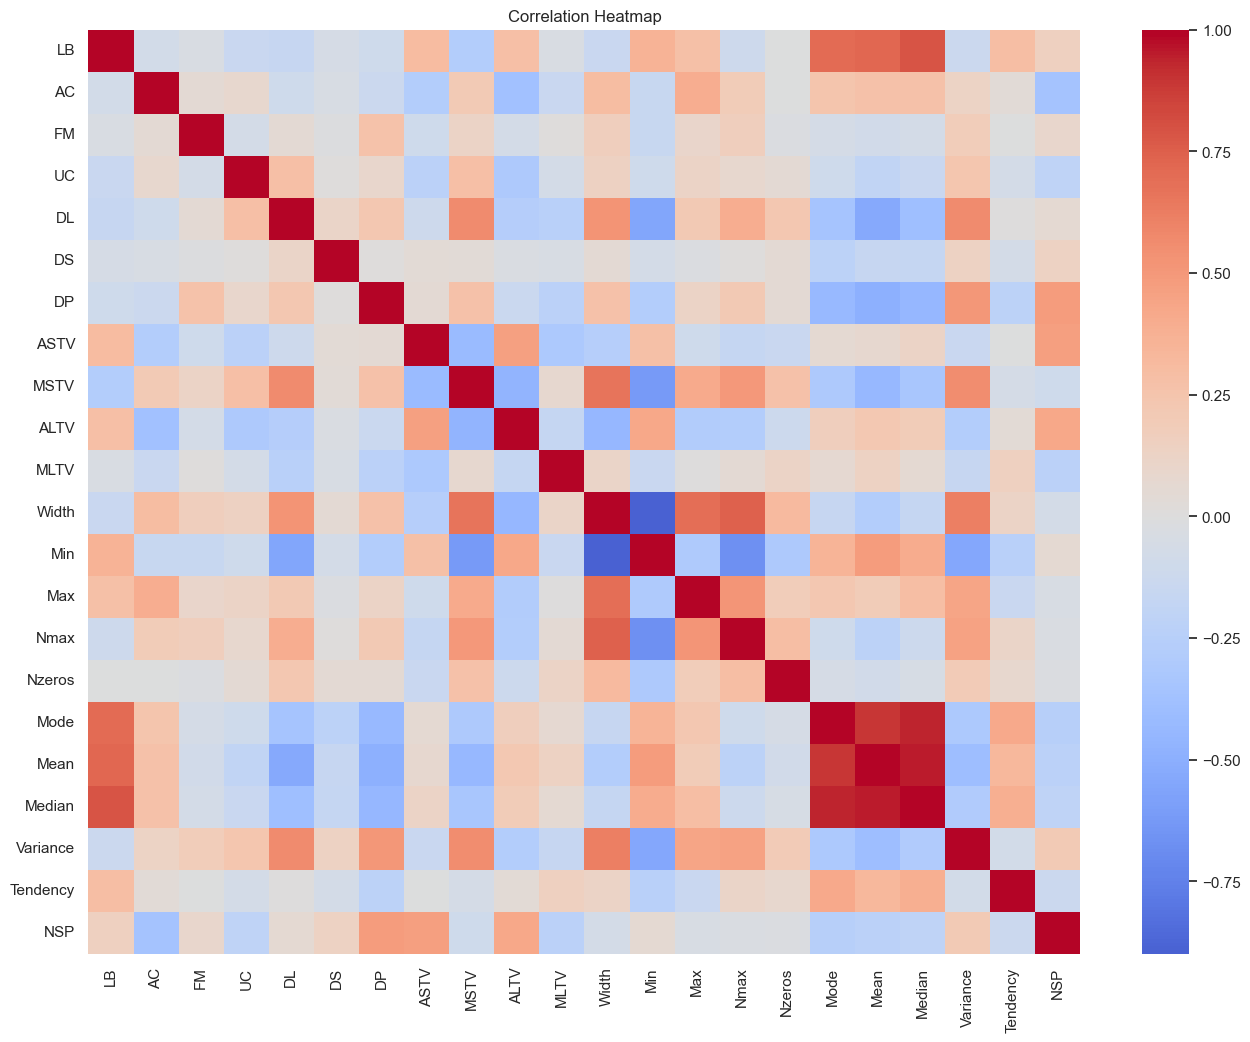

In [39]:
# Correlation heatmap
plt.figure(figsize=(16, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


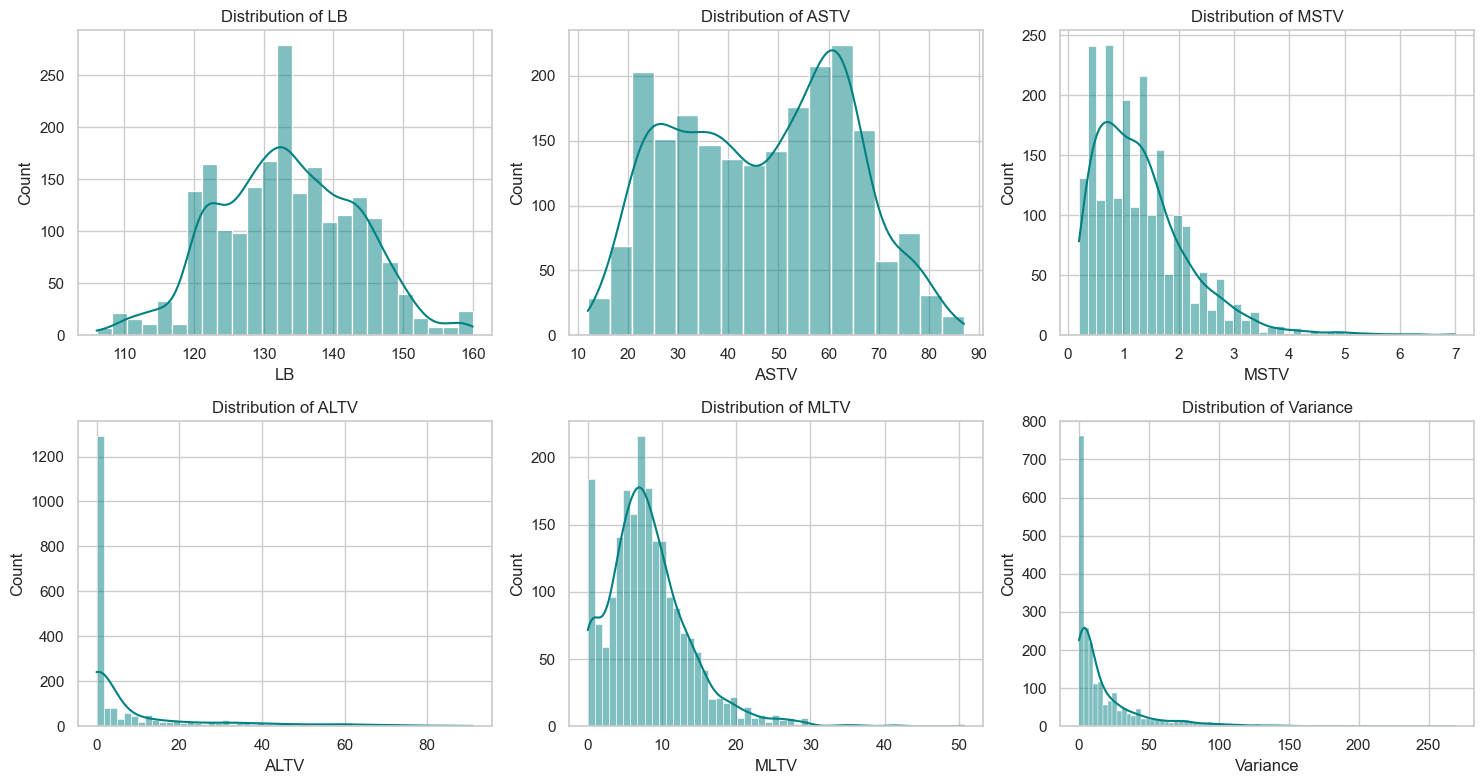

In [40]:
# Distribution plots for a few key features
key_features = ["LB", "ASTV", "MSTV", "ALTV", "MLTV", "Variance"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feature in zip(axes, key_features):
    sns.histplot(df[feature], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {feature}")
plt.tight_layout()
plt.show()


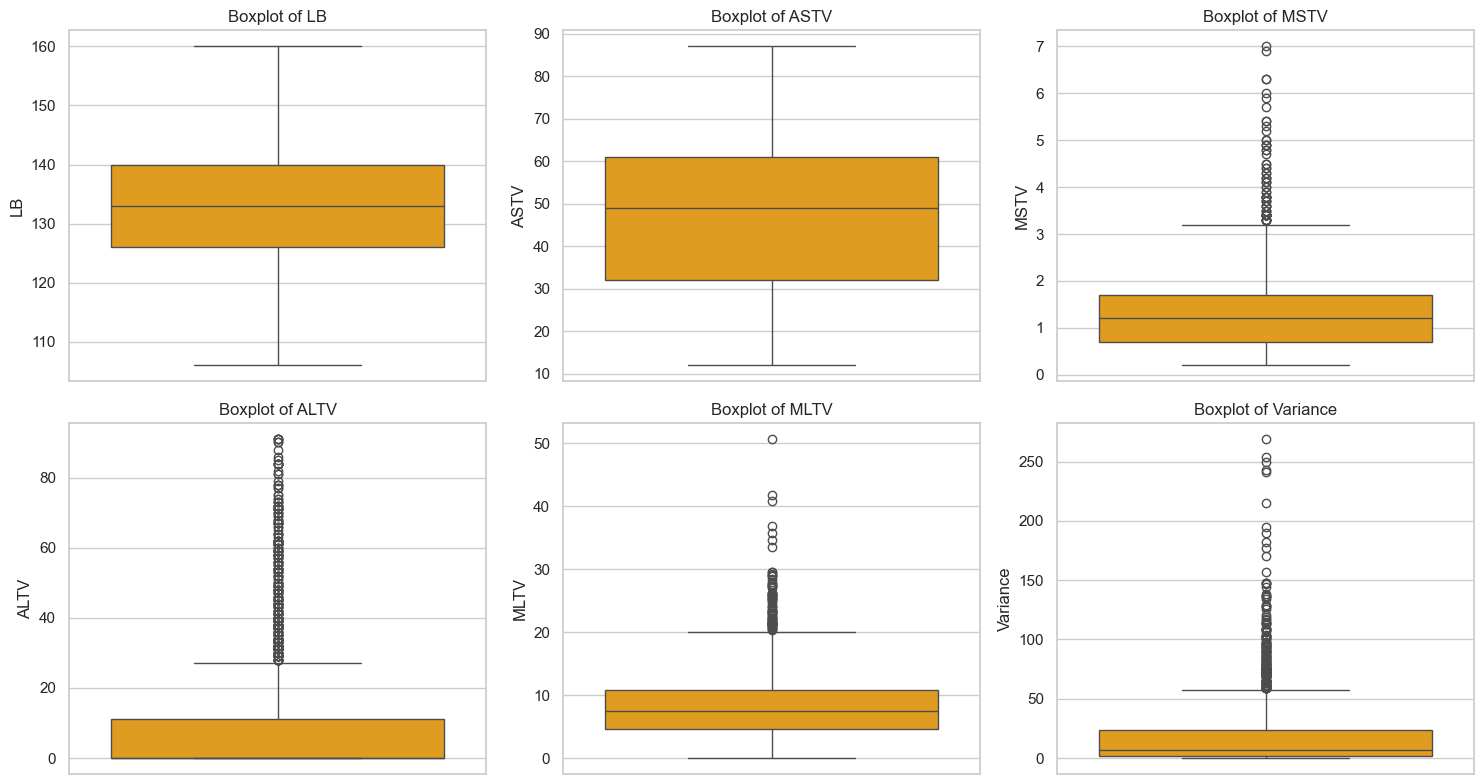

In [41]:
# Boxplots to inspect potential outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, feature in zip(axes, key_features):
    sns.boxplot(y=df[feature], ax=ax, color="orange")
    ax.set_title(f"Boxplot of {feature}")
plt.tight_layout()
plt.show()


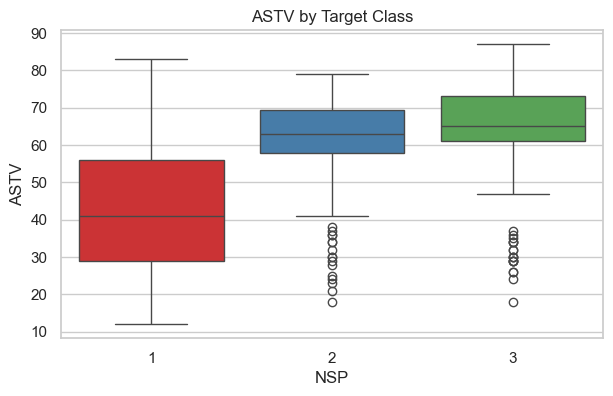

In [42]:

# Feature vs target analysis (example with ASTV)
plt.figure(figsize=(7, 4))
sns.boxplot(x="NSP", y="ASTV", data=df, hue="NSP", palette="Set1", legend=False)
plt.title("ASTV by Target Class")
plt.xlabel("NSP")
plt.ylabel("ASTV")
plt.show()


Use these plots to spot skewed features, outliers, and possible class-separating signals. This helps us justify scaling, outlier handling, and model selection.

## 5. Preprocessing, split, and outlier handling

Objective: remove duplicates, separate features/target, create a stratified train-test split, and apply an IQR-based clipping strategy for outliers (fit on train, apply to train/test).

In [43]:
# Remove duplicate rows, if any.
duplicates_before = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
duplicates_after = df.duplicated().sum()
print(f"Duplicates before: {duplicates_before}, after removal: {duplicates_after}")


Duplicates before: 12, after removal: 0


In [44]:
X = df.drop(columns=["NSP"])
y = df["NSP"]

In [45]:
# Stratified split keeps class proportions similar in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [46]:
def compute_iqr_bounds(dataframe):
    q1 = dataframe.quantile(0.25)
    q3 = dataframe.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper


In [47]:
train_lower, train_upper = compute_iqr_bounds(X_train)

# Clip outliers based on training bounds only (to avoid test leakage).
X_train_clipped = X_train.clip(lower=train_lower, upper=train_upper, axis=1)
X_test_clipped = X_test.clip(lower=train_lower, upper=train_upper, axis=1)

print("Train shape:", X_train_clipped.shape)
print("Test shape:", X_test_clipped.shape)

Train shape: (1691, 21)
Test shape: (423, 21)



Now we have cleaned and split data ready for modeling. Outlier clipping here is intentionally simple and beginner friendly; more advanced options can be tested later.

## 6. Quick feature importance check

Objective: use a Random Forest model to estimate which features seem most informative before full model comparison.

In [48]:
rf_for_importance = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

rf_for_importance.fit(X_train_clipped, y_train)

feature_importance_df = pd.DataFrame({
    "feature": X_train_clipped.columns,
    "importance": rf_for_importance.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(10))


,feature,importance
7,ASTV,0.139579
17,Mean,0.104516
18,Median,0.087211
10,MLTV,0.081853
1,AC,0.079795
9,ALTV,0.068342
16,Mode,0.067216
8,MSTV,0.064992
0,LB,0.054082
19,Variance,0.044267


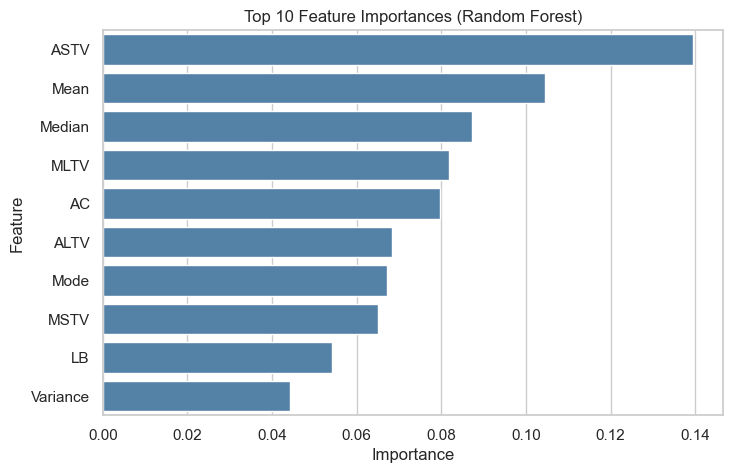

In [49]:

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_df.head(10), x="importance", y="feature", color="steelblue")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

This ranking is a guide, not an absolute truth. It helps explain model behavior and can support future feature selection experiments.

## 7. Train and evaluate multiple models

Objective: compare Logistic Regression, Random Forest, SVM, KNN, and XGBoost (if installed) using pipelines, class-imbalance handling, and consistent metrics.

XGBoost not available. Continuing without it.
Use SMOTE: True

Training: Logistic Regression
Classification report:
              precision    recall  f1-score   support

           1       0.96      0.90      0.93       330
           2       0.57      0.78      0.66        58
           3       0.78      0.80      0.79        35

    accuracy                           0.87       423
   macro avg       0.77      0.83      0.79       423
weighted avg       0.89      0.87      0.88       423



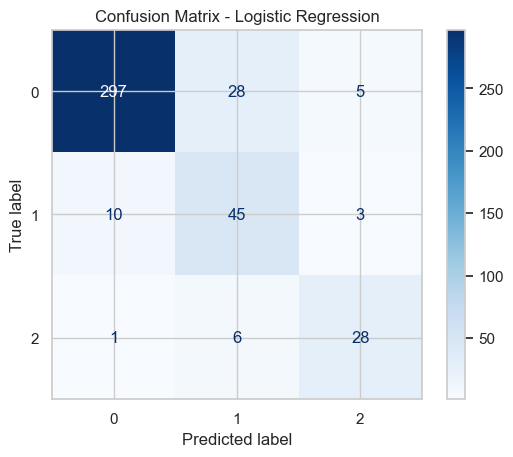


Training: Random Forest
Classification report:
              precision    recall  f1-score   support

           1       0.96      0.97      0.97       330
           2       0.79      0.71      0.75        58
           3       0.89      0.91      0.90        35

    accuracy                           0.93       423
   macro avg       0.88      0.86      0.87       423
weighted avg       0.93      0.93      0.93       423



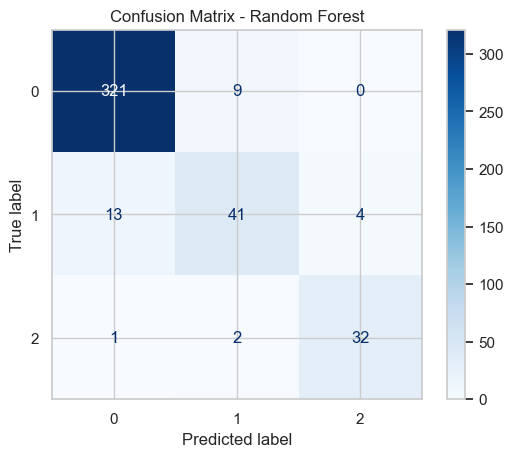


Training: SVM
Classification report:
              precision    recall  f1-score   support

           1       0.98      0.93      0.96       330
           2       0.65      0.84      0.74        58
           3       0.88      0.86      0.87        35

    accuracy                           0.91       423
   macro avg       0.84      0.88      0.85       423
weighted avg       0.93      0.91      0.92       423



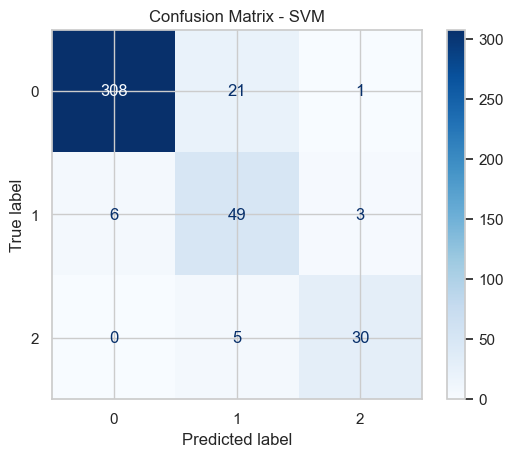


Training: KNN
Classification report:
              precision    recall  f1-score   support

           1       0.97      0.88      0.93       330
           2       0.52      0.79      0.63        58
           3       0.79      0.77      0.78        35

    accuracy                           0.86       423
   macro avg       0.76      0.82      0.78       423
weighted avg       0.90      0.86      0.87       423



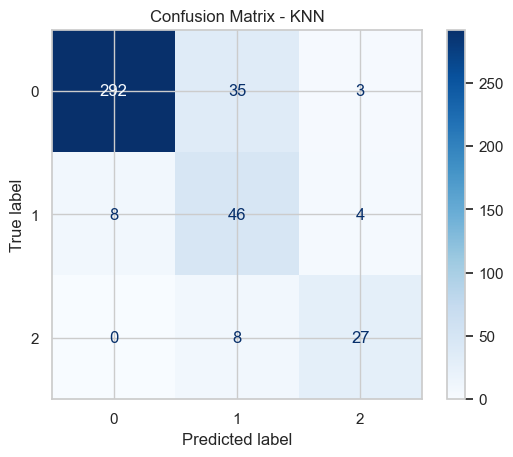

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Random Forest,0.931442,0.878520,0.864637,0.870759
1,SVM,0.914894,0.838859,0.878435,0.854310
2,Logistic Regression,0.874704,0.770561,0.825287,0.792234
3,KNN,0.862884,0.761435,0.816460,0.778481


Best baseline model: Random Forest


In [50]:
def build_pipeline(model_name, model, use_smote):
    steps = [("imputer", SimpleImputer(strategy="median"))]

    # Distance/linear models benefit from scaling.
    if model_name in {"Logistic Regression", "SVM", "KNN"}:
        steps.append(("scaler", StandardScaler()))

    # SMOTE is applied only on training folds inside the pipeline.
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))

    steps.append(("model", model))
    return ImbPipeline(steps=steps)

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RANDOM_STATE),
    "SVM": SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

# XGBoost is optional. Skip gracefully if unavailable.
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE
    )
    print("XGBoost available and included.")
except Exception:
    print("XGBoost not available. Continuing without it.")

imbalance_ratio_train = y_train.value_counts().max() / y_train.value_counts().min()
use_smote = imbalance_ratio_train > 1.5
print(f"Use SMOTE: {use_smote}")

results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"\nTraining: {name}")
    pipeline = build_pipeline(name, model, use_smote=use_smote)
    pipeline.fit(X_train_clipped, y_train)

    y_pred = pipeline.predict(X_test_clipped)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-score (macro)": f1
    })

    trained_pipelines[name] = pipeline

    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

results_df = pd.DataFrame(results).sort_values("F1-score (macro)", ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_baseline_pipeline = trained_pipelines[best_model_name]
print(f"Best baseline model: {best_model_name}")


Use the summary table to compare models fairly. We prioritize **macro F1-score** because this metric balances performance across all classes in an imbalanced multiclass setting.

## 8. hyperparameter tuning for best model

Objective: improve the best baseline model using cross-validated hyperparameter search with `RandomizedSearchCV` and `StratifiedKFold`.

In [51]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 50],
        "model__solver": ["lbfgs", "saga"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "SVM": {
        "model__C": [0.5, 1, 2, 5, 10],
        "model__gamma": ["scale", "auto"]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 0.9, 1.0]
    }
}

search_space = param_grids.get(best_model_name, {})
if len(search_space) == 0:
    print("No search space found for best model. Using baseline model as final.")
    tuned_search = None
    final_model = best_baseline_pipeline
else:
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    tuned_search = RandomizedSearchCV(
        estimator=best_baseline_pipeline,
        param_distributions=search_space,
        n_iter=12,
        scoring="f1_macro",
        n_jobs=-1,
        cv=cv_strategy,
        verbose=1,
        random_state=RANDOM_STATE
    )

    tuned_search.fit(X_train_clipped, y_train)
    print("Best parameters:")
    print(tuned_search.best_params_)
    print(f"Best CV score (f1_macro): {tuned_search.best_score_:.4f}")

    final_model = tuned_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:
{'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}
Best CV score (f1_macro): 0.8547



This step returns the best hyperparameters based on cross-validation. The selected model (`final_model`) is what we will evaluate, interpret, and save.

## 9. Final evaluation and interpretation

Objective: evaluate the tuned final model on the test set and provide an interpretation plot (feature importances for tree models or coefficients for logistic regression).

Final test accuracy: 0.9338
Final test precision (macro): 0.8808
Final test recall (macro): 0.8704
Final test f1-score (macro): 0.8750

Final classification report:
              precision    recall  f1-score   support

           1       0.96      0.97      0.97       330
           2       0.79      0.72      0.76        58
           3       0.89      0.91      0.90        35

    accuracy                           0.93       423
   macro avg       0.88      0.87      0.88       423
weighted avg       0.93      0.93      0.93       423



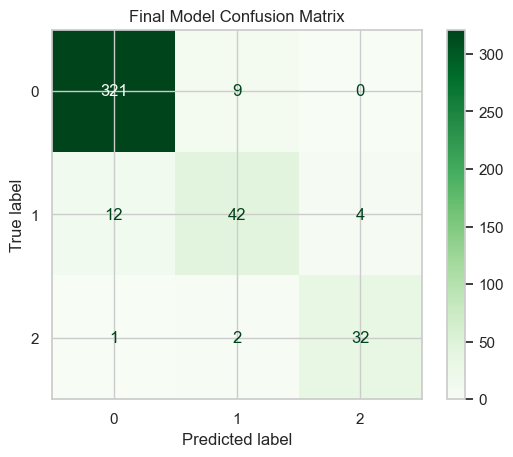

,feature,importance
7,ASTV,0.142047
17,Mean,0.107657
18,Median,0.091450
8,MSTV,0.078422
1,AC,0.076948
10,MLTV,0.074675
9,ALTV,0.069886
16,Mode,0.064069
0,LB,0.056261
19,Variance,0.044978


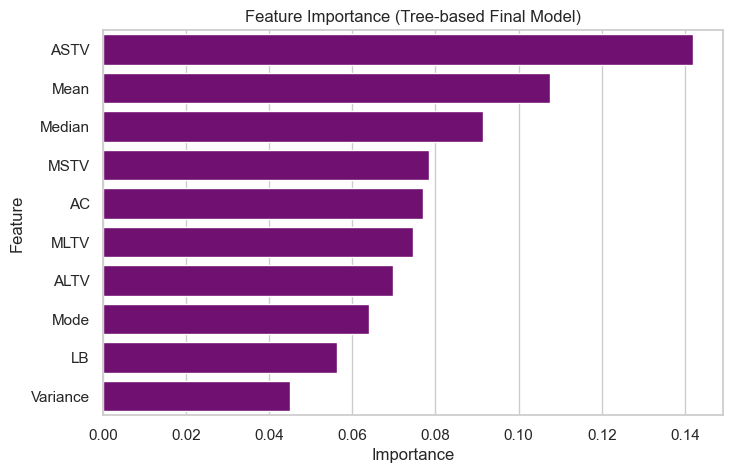

In [52]:
y_test_pred = final_model.predict(X_test_clipped)

final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision, final_recall, final_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)

print(f"Final test accuracy: {final_accuracy:.4f}")
print(f"Final test precision (macro): {final_precision:.4f}")
print(f"Final test recall (macro): {final_recall:.4f}")
print(f"Final test f1-score (macro): {final_f1:.4f}")

print("\nFinal classification report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

cm_final = confusion_matrix(y_test, y_test_pred)
disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final)
disp_final.plot(cmap="Greens")
plt.title("Final Model Confusion Matrix")
plt.show()

# Interpretation block
model_step = final_model.named_steps["model"]
importance_df = None

if hasattr(model_step, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": X_train_clipped.columns,
        "importance": model_step.feature_importances_
    }).sort_values("importance", ascending=False)
    title = "Feature Importance (Tree-based Final Model)"
elif hasattr(model_step, "coef_"):
    coef_values = np.abs(model_step.coef_).mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": X_train_clipped.columns,
        "importance": coef_values
    }).sort_values("importance", ascending=False)
    title = "Average Absolute Coefficients (Logistic Final Model)"
else:
    print("Model-specific interpretation is not directly available for this model type.")

if importance_df is not None:
    display(importance_df.head(10))
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df.head(10), x="importance", y="feature", color="purple")
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


The confusion matrix and classification report show where the model performs well and where it struggles. The interpretation chart helps explain which features influence predictions the most.

## 10. Serialize model and demonstrate loading

Objective: save the trained model as `model.pkl`, optionally save preprocessing steps, then load the model back and run sample predictions.

In [53]:
with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)
print("Saved final model to model.pkl")

# Save preprocessing-only pipeline (if these steps exist in the final pipeline).
preprocess_steps = []
for step_name in ["imputer", "scaler"]:
    if step_name in final_model.named_steps:
        preprocess_steps.append((step_name, final_model.named_steps[step_name]))

if preprocess_steps:
    preprocessing_pipeline = SkPipeline(preprocess_steps)
    with open("preprocessing_pipeline.pkl", "wb") as f:
        pickle.dump(preprocessing_pipeline, f)
    print("Saved preprocessing pipeline to preprocessing_pipeline.pkl")
else:
    print("No separate preprocessing pipeline to save.")

# Demonstrate loading and prediction.
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample_X = X_test_clipped.head(5)
sample_predictions = loaded_model.predict(sample_X)

print("Sample predictions for first 5 test rows:")
print(sample_predictions)

sample_result_df = sample_X.copy()
sample_result_df["Predicted_NSP"] = sample_predictions
display(sample_result_df)

Saved final model to model.pkl
Saved preprocessing pipeline to preprocessing_pipeline.pkl
Sample predictions for first 5 test rows:
[1 1 3 1 1]


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,Predicted_NSP
1703,131,0.007965,0.002655,0.003540,0.000885,0.0,0.0,55,1.9,0.0,...,84,169,6,0,150.0,140,145,22.0,1,1
1006,139,0.006312,0.000000,0.004509,0.000000,0.0,0.0,39,0.8,0.0,...,136,170,1,0,144.0,146,146,3.0,-1,1
1755,120,0.000000,0.000000,0.004451,0.007418,0.0,0.0,64,1.3,0.0,...,69,154,3,0,100.5,97,98,48.0,-1,3
1525,136,0.000000,0.000000,0.006071,0.000000,0.0,0.0,53,0.5,27.5,...,134,151,2,0,144.0,142,144,0.0,0,1
635,138,0.000000,0.004484,0.000000,0.000000,0.0,0.0,38,1.2,0.0,...,71,155,4,0,144.0,140,142,5.0,1,1



You can now reuse `model.pkl` for inference in another script or app. The sample prediction output confirms that loading from disk works correctly.

## Final project summary

Objective: present a concise summary of best model, key performance numbers, insights, and limitations.

In [54]:
summary = {
    "Best model": best_model_name,
    "Final test accuracy": round(final_accuracy, 4),
    "Final test macro precision": round(final_precision, 4),
    "Final test macro recall": round(final_recall, 4),
    "Final test macro F1": round(final_f1, 4),
    "Key insight": "Variability-related CTG features are usually strong predictors.",
    "Limitation": "Results depend on one dataset snapshot; external validation is still recommended."
}

display(pd.DataFrame(summary.items(), columns=["Item", "Value"]))

,Item,Value
0,Best model,Random Forest
1,Final test accuracy,0.9338
2,Final test macro precision,0.8808
3,Final test macro recall,0.8704
4,Final test macro F1,0.875
5,Key insight,Variability-related CTG features are usually s...
6,Limitation,Results depend on one dataset snapshot; extern...


In [55]:
import numpy as np
import pandas as pd
import streamlit as st
import sklearn
import imblearn

print(np.__version__)
print(pd.__version__)
print(st.__version__)
print(sklearn.__version__)
print(imblearn.__version__)

2.4.4
3.0.3
1.57.0
1.8.0
0.14.1
